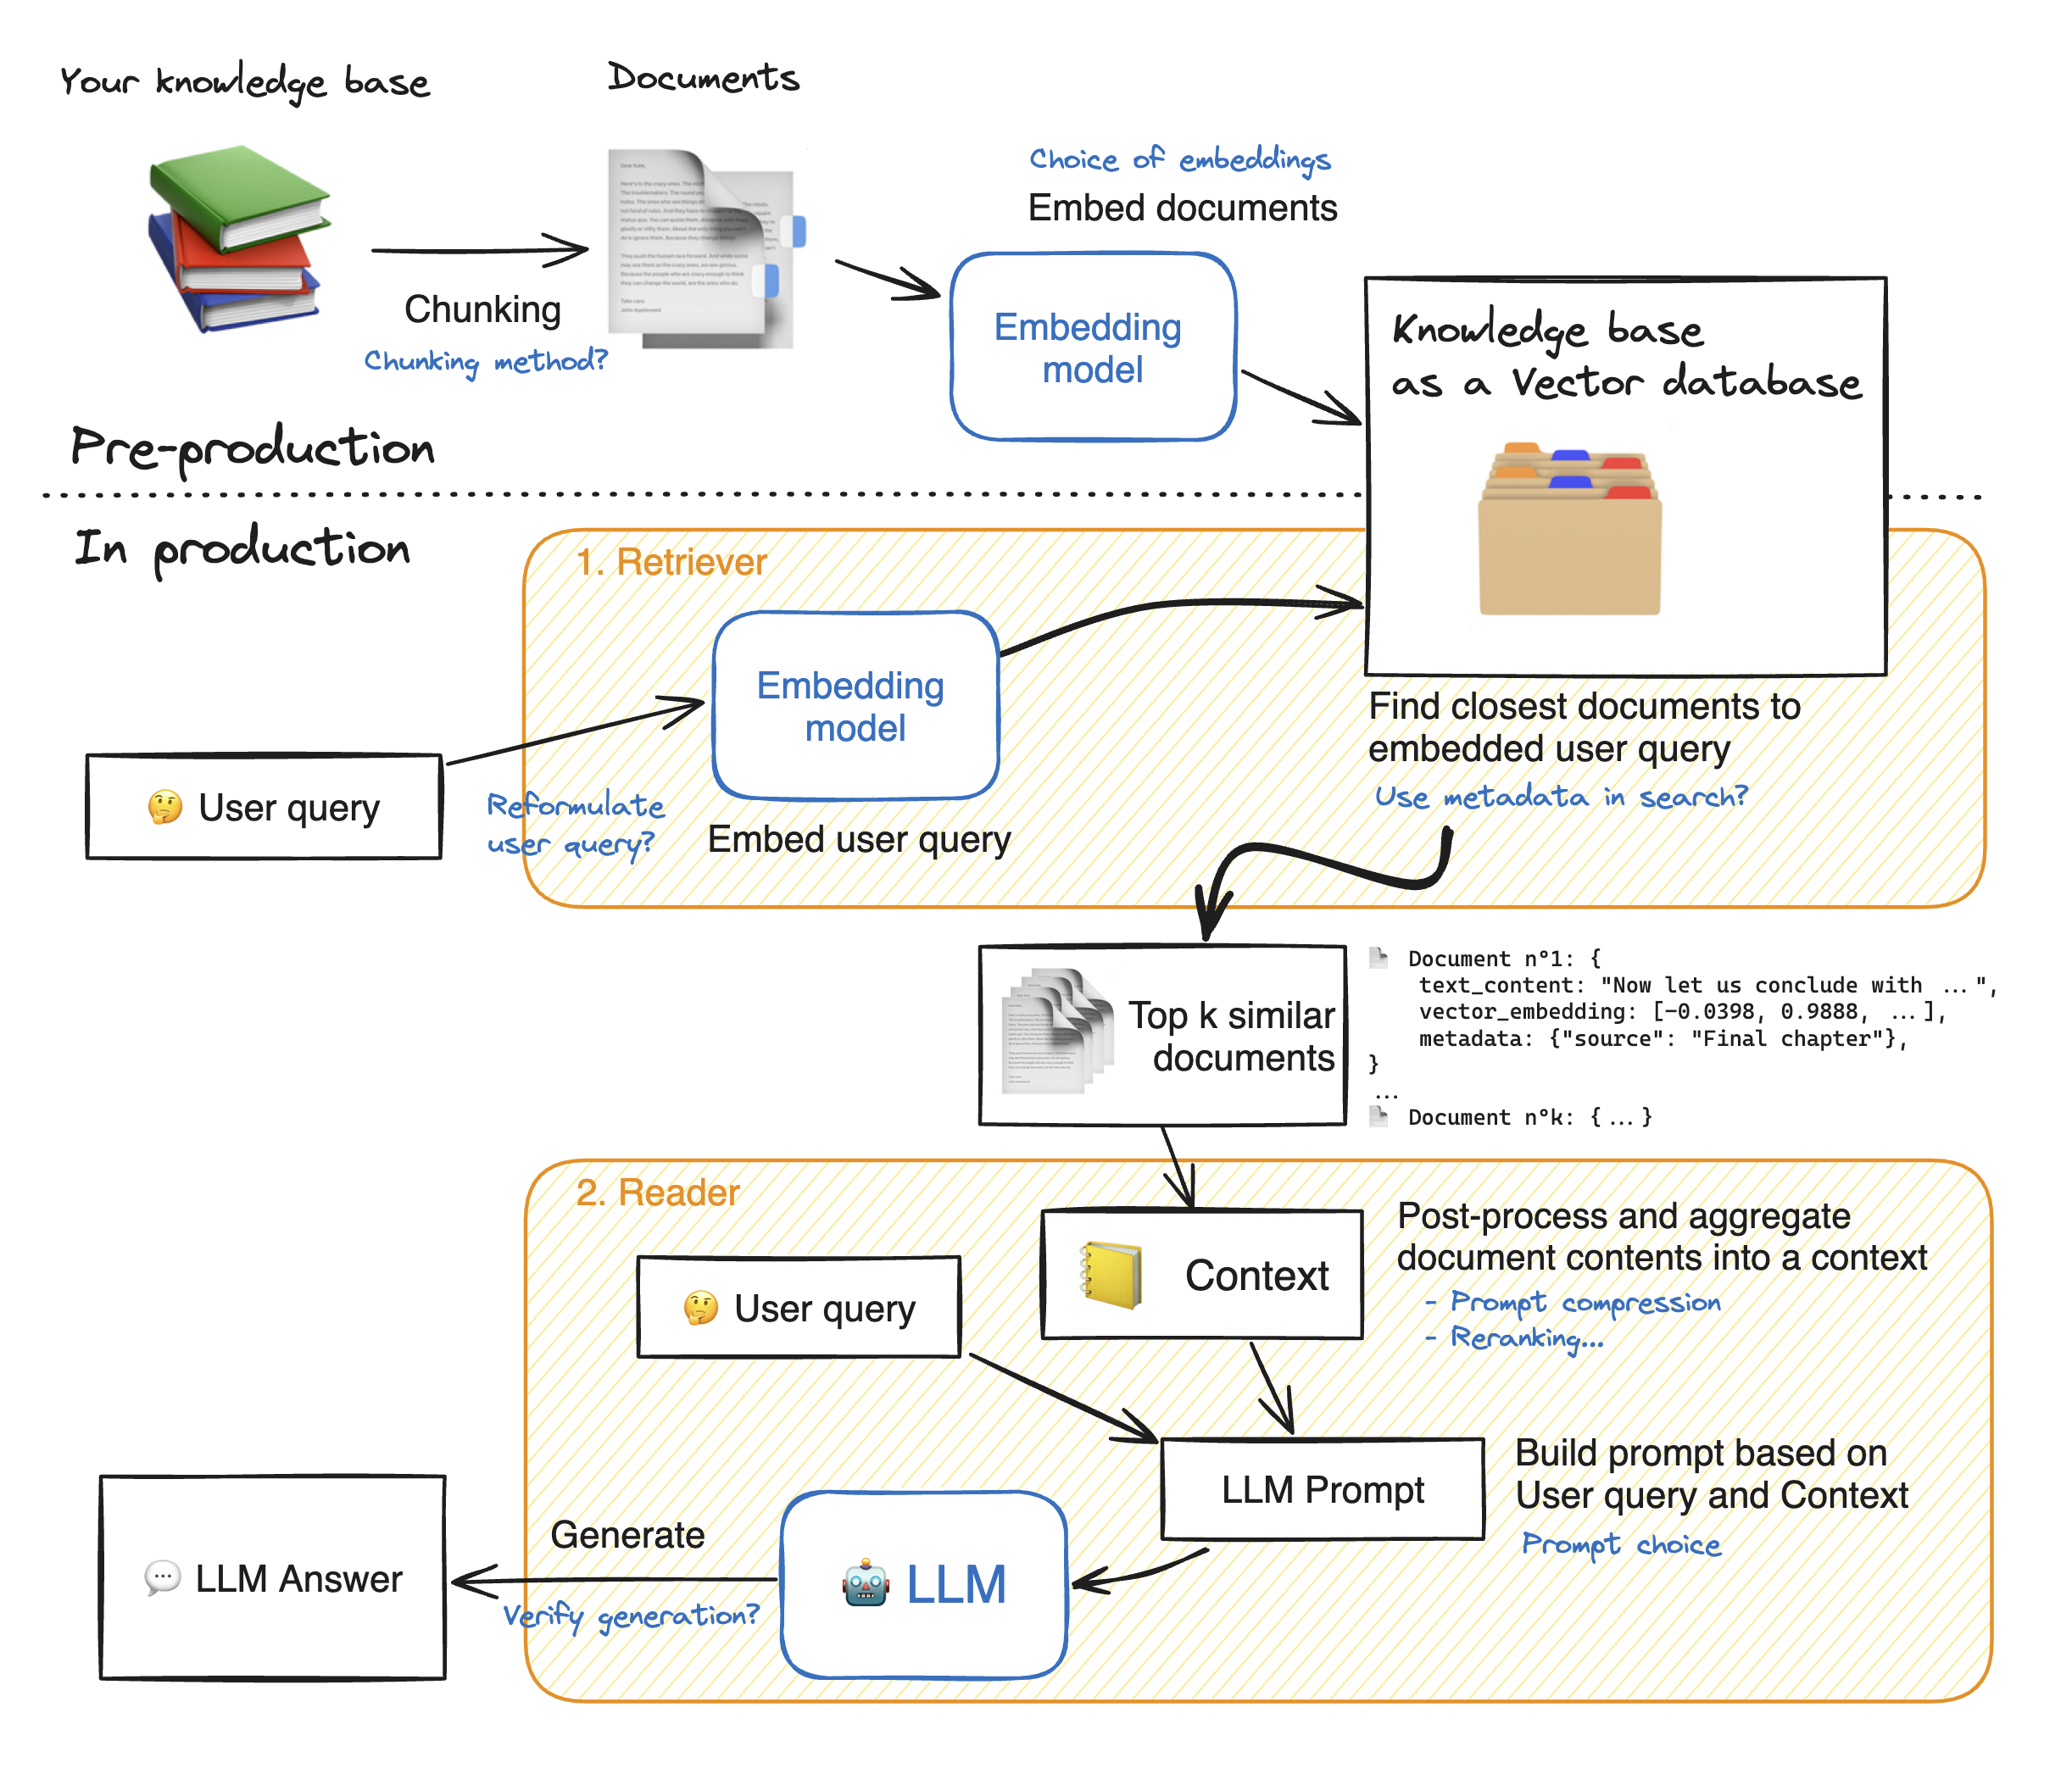

In [1]:
# !pip install -q torch transformers accelerate bitsandbytes langchain sentence-transformers faiss-cpu openpyxl pacmap datasets langchain-community 

In [2]:
# pip install huggingface_hub

In [3]:
from tqdm.notebook import tqdm
import pandas as pd
from typing import Optional, List, Tuple
from datasets import Dataset
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)

In [4]:
#Load your knowledge base
import datasets

ds = datasets.load_dataset("m-ric/huggingface_doc", split="train")

In [5]:
#pip install "langchain[all]"


In [6]:
# !pip install ipywidgets
# !jupyter labextension install @jupyter-widgets/jupyterlab-manager


In [7]:
# pip install --upgrade jupyter ipywidgets

In [8]:
from langchain.docstore.document import Document as LangchainDocument

RAW_KNOWLEDGE_BASE = [
    LangchainDocument(page_content=doc["text"], metadata={"source": doc["source"]}) for doc in tqdm(ds)
]

  0%|          | 0/2647 [00:00<?, ?it/s]

##1. Retriever - embeddings
The retriever acts like an internal search engine: given the user query, it returns a few relevant snippets from your knowledge base.
These snippets will then be fed to the Reader Model to help it generate its answer.
* So our objective here is, given a user question, to find the most relevant snippets from our knowledge base to answer that question.




In [9]:
'''Recursive chunking breaks down the text into smaller parts step by step using a given list of separators sorted from the most important to the least important separator. If the first split doesn’t give the right size or shape of chunks, the method repeats itself on the new chunks using a different separator. For instance with the list of separators ["\n\n", "\n", ".", ""]:

The method will first break down the document wherever there is a double line break "\n\n".
Resulting documents will be split again on simple line breaks "\n", then on sentence ends ".".
Finally, if some chunks are still too big, they will be split whenever they overflow the maximum size.'''

'Recursive chunking breaks down the text into smaller parts step by step using a given list of separators sorted from the most important to the least important separator. If the first split doesn’t give the right size or shape of chunks, the method repeats itself on the new chunks using a different separator. For instance with the list of separators ["\n\n", "\n", ".", ""]:\n\nThe method will first break down the document wherever there is a double line break "\n\n".\nResulting documents will be split again on simple line breaks "\n", then on sentence ends ".".\nFinally, if some chunks are still too big, they will be split whenever they overflow the maximum size.'

In [10]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

# We use a hierarchical list of separators specifically tailored for splitting Markdown documents
# This list is taken from LangChain's MarkdownTextSplitter class
MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n___+\n",
    "\n\n",
    "\n",
    " ",
    "",
]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # The maximum number of characters in a chunk: we selected this value arbitrarily
    chunk_overlap=100,  # The number of characters to overlap between chunks
    add_start_index=True,  # If `True`, includes chunk's start index in metadata
    strip_whitespace=True,  # If `True`, strips whitespace from the start and end of every document
    separators=MARKDOWN_SEPARATORS,
)

docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
    docs_processed += text_splitter.split_documents([doc])

In [11]:
'''We also have to keep in mind that when embedding documents, we will use an embedding model that accepts a certain maximum sequence length max_seq_length.

So we should make sure that our chunk sizes are below this limit because any longer chunk will be truncated before processing, thus losing relevancy.'''

'We also have to keep in mind that when embedding documents, we will use an embedding model that accepts a certain maximum sequence length max_seq_length.\n\nSo we should make sure that our chunk sizes are below this limit because any longer chunk will be truncated before processing, thus losing relevancy.'

In [12]:
# !pip install sentence-transformers

Model's maximum sequence length: 512


  0%|          | 0/31085 [00:00<?, ?it/s]

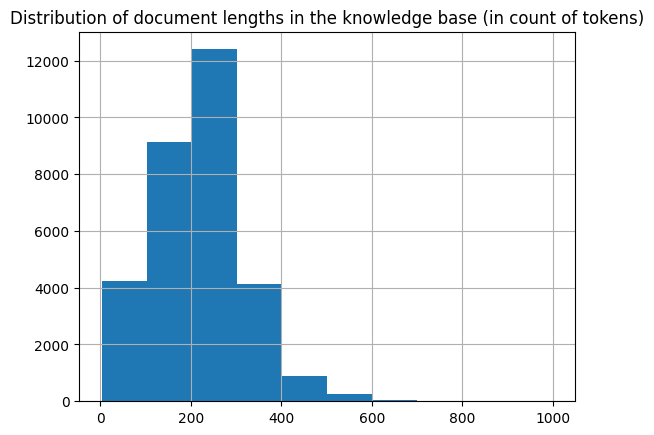

In [13]:
from sentence_transformers import SentenceTransformer

# To get the value of the max sequence_length, we will query the underlying `SentenceTransformer` object used in the RecursiveCharacterTextSplitter
print(f"Model's maximum sequence length: {SentenceTransformer('thenlper/gte-small').max_seq_length}")

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("thenlper/gte-small")
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]

# Plot the distribution of document lengths, counted as the number of tokens
fig = pd.Series(lengths).hist()
plt.title("Distribution of document lengths in the knowledge base (in count of tokens)")
plt.show()

### Model's maximum sequence length: 512
As you can see, the chunk lengths are not aligned with our limit of 512 tokens, and some documents are above the limit, thus some part of them will be lost in truncation!

So we should change the RecursiveCharacterTextSplitter class to count length in number of tokens instead of number of characters.
Then we can choose a specific chunk size, here we would choose a lower threshold than 512:
Smaller documents could allow the split to focus more on specific ideas.
But too small chunks would split sentences in half, thus losing meaning again: the proper tuning is a matter of balance.

  0%|          | 0/16776 [00:00<?, ?it/s]

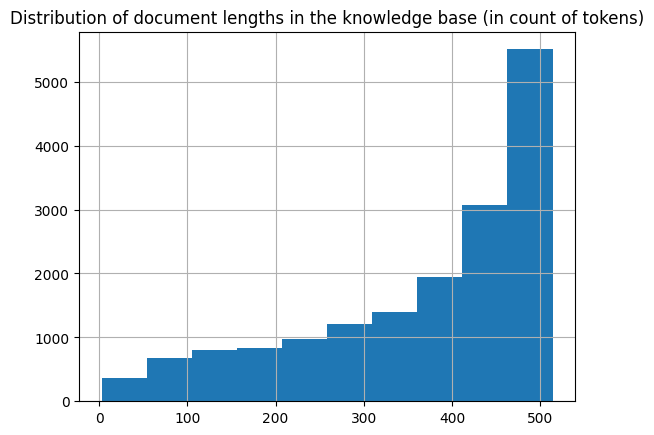

In [14]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer

EMBEDDING_MODEL_NAME = "thenlper/gte-small"


def split_documents(
    chunk_size: int,
    knowledge_base: List[LangchainDocument],
    tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME,
) -> List[LangchainDocument]:
    """
    Split documents into chunks of maximum size `chunk_size` tokens and return a list of documents.
    """
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        AutoTokenizer.from_pretrained(tokenizer_name),
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10),
        add_start_index=True,
        strip_whitespace=True,
        separators=MARKDOWN_SEPARATORS,
    )

    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])

    # Remove duplicates
    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)

    return docs_processed_unique


docs_processed = split_documents(
    512,  # We choose a chunk size adapted to our model
    RAW_KNOWLEDGE_BASE,
    tokenizer_name=EMBEDDING_MODEL_NAME,
)

# Let's visualize the chunk sizes we would have in tokens from a common model
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]
fig = pd.Series(lengths).hist()
plt.title("Distribution of document lengths in the knowledge base (in count of tokens)")
plt.show()

In [15]:
## .2 Building the vector database
##We want to compute the embeddings for all the chunks of our knowledge base: to learn more about sentence embeddings
'''How does retrieval work?
Once the chunks are all embedded, we store them in a vector database. When the user types in a query, it gets embedded by the same model previously used, and a similarity search returns the closest documents from the vector database.

The technical challenge is thus, given a query vector, to quickly find the nearest neighbors of this vector in the vector database. To do this, we need to choose two things: a distance, and a search algorithm to find the nearest neighbors quickly within a database of thousands of records.

Nearest Neighbor search algorithm
There are plentiful choices for the nearest neighbor search algorithm: we go with Facebook’s FAISS since FAISS is performant enough for most use cases, and it is well known and thus widely implemented.

Distances
'''

'How does retrieval work?\nOnce the chunks are all embedded, we store them in a vector database. When the user types in a query, it gets embedded by the same model previously used, and a similarity search returns the closest documents from the vector database.\n\nThe technical challenge is thus, given a query vector, to quickly find the nearest neighbors of this vector in the vector database. To do this, we need to choose two things: a distance, and a search algorithm to find the nearest neighbors quickly within a database of thousands of records.\n\nNearest Neighbor search algorithm\nThere are plentiful choices for the nearest neighbor search algorithm: we go with Facebook’s FAISS since FAISS is performant enough for most use cases, and it is well known and thus widely implemented.\n\nDistances\n'

In [16]:
# pip install -U langchain-community

In [17]:
pip install -U langchain-community

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [18]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},  # Set `True` for cosine similarity
)

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_processed, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

/tmp/ipykernel_8087/789955820.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


In [19]:
pip install faiss-cpu

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [20]:
KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_processed, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

In [21]:
# Embed a user query in the same space
user_query = "How to create a pipeline object?"
query_vector = embedding_model.embed_query(user_query)

In [22]:
# !pip install pacmap
# !pip install plotly

import pacmap
import numpy as np
import plotly.express as px

embedding_projector = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0, random_state=1)

embeddings_2d = [
    list(KNOWLEDGE_VECTOR_DATABASE.index.reconstruct_n(idx, 1)[0]) for idx in range(len(docs_processed))
] + [query_vector]

# Fit the data (the index of transformed data corresponds to the index of the original data)
documents_projected = embedding_projector.fit_transform(np.array(embeddings_2d), init="pca")

In [23]:
df = pd.DataFrame.from_dict(
    [
        {
            "x": documents_projected[i, 0],
            "y": documents_projected[i, 1],
            "source": docs_processed[i].metadata["source"].split("/")[1],
            "extract": docs_processed[i].page_content[:100] + "...",
            "symbol": "circle",
            "size_col": 4,
        }
        for i in range(len(docs_processed))
    ]
    + [
        {
            "x": documents_projected[-1, 0],
            "y": documents_projected[-1, 1],
            "source": "User query",
            "extract": user_query,
            "size_col": 100,
            "symbol": "star",
        }
    ]
)

# Visualize the embedding
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="source",
    hover_data="extract",
    size="size_col",
    symbol="symbol",
    color_discrete_map={"User query": "black"},
    width=1000,
    height=700,
)
fig.update_traces(
    marker=dict(opacity=1, line=dict(width=0, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)
fig.update_layout(
    legend_title_text="<b>Chunk source</b>",
    title="<b>2D Projection of Chunk Embeddings via PaCMAP</b>",
)
fig.show()

In [24]:
print(f"\nStarting retrieval for {user_query=}...")
retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=5)
print("\n==================================Top document==================================")
print(retrieved_docs[0].page_content)
print("==================================Metadata==================================")
print(retrieved_docs[0].metadata)


Starting retrieval for user_query='How to create a pipeline object?'...

==================================Top document==================================
```
</tf>
</frameworkcontent>

## Pipeline

<Youtube id="tiZFewofSLM"/>

The [`pipeline`] is the easiest and fastest way to use a pretrained model for inference. You can use the [`pipeline`] out-of-the-box for many tasks across different modalities, some of which are shown in the table below:

<Tip>

For a complete list of available tasks, check out the [pipeline API reference](./main_classes/pipelines).

</Tip>
==================================Metadata==================================
{'source': 'huggingface/transformers/blob/main/docs/source/en/quicktour.md', 'start_index': 1585}


In [25]:
# pip install bitsandbytes
# !pip install transformers torch
!pip install "accelerate>=0.26.0"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [26]:
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

READER_MODEL_NAME = "HuggingFaceH4/zephyr-7b-beta"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model = AutoModelForCausalLM.from_pretrained(READER_MODEL_NAME, quantization_config=bnb_config)
tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)

READER_LLM = pipeline(
    model=model,
    tokenizer=tokenizer,
    task="text-generation",
    do_sample=True,
    temperature=0.2,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=500,
)

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Device set to use cuda:0


In [ ]:
READER_LLM("What is 4+4? Answer:")

In [ ]:
'''The RAG prompt template below is what we will feed to the Reader LLM: it is important to have it formatted in the Reader LLM’s chat template.'''
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer.""",
    },
    {
        "role": "user",
        "content": """Context:
{context}
---
Now here is the question you need to answer.

Question: {question}""",
    },
]
RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)
print(RAG_PROMPT_TEMPLATE)

<|system|>
Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer.</s>
<|user|>
Context:
{context}
---
Now here is the question you need to answer.

Question: {question}</s>
<|assistant|>



In [ ]:
''' test our Reader on our previously retrieved documents!'''
retrieved_docs_text = [doc.page_content for doc in retrieved_docs]  # We only need the text of the documents
context = "\nExtracted documents:\n"
context += "".join([f"Document {str(i)}:::\n" + doc for i, doc in enumerate(retrieved_docs_text)])

final_prompt = RAG_PROMPT_TEMPLATE.format(question="How to create a pipeline object?", context=context)

# Redact an answer
answer = READER_LLM(final_prompt)[0]["generated_text"]
print(answer)

To create a pipeline object, follow these steps:

1. Define the inputs and outputs of your pipeline. Decide what type of data your pipeline will accept as input and what output format it will produce.

2. Create a subclass of the `Pipeline` class provided by the `transformers` library. This subclass will inherit the necessary methods for implementing your pipeline.

3. Implement the `_sanitize_parameters` method to sanitize any parameters passed to the pipeline. This method should return a tuple containing the preprocess, forward, and postprocess keyword arguments.

4. Implement the `preprocess` method to preprocess the input data before passing it to the model. This method should return a dictionary containing the processed input data.

5. Implement the `_forward` method to perform the actual computation using the model and scheduler. This method should return the output of the computation.

6. Implement the `postprocess` method to postprocess the output data produced by the model. Th

In [ ]:
#2.3. Reranking
#A good option for RAG is to retrieve more documents than you want in the end, then rerank the results with a more powerful retrieval model before keeping only the top_k.
# !pip install ragatouille

from ragatouille import RAGPretrainedModel

RERANKER = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")   

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached ragatouille-0.0.9.post2-py3-none-any.whl.metadata (28 kB)
  Using cached llama_index-0.12.43-py3-none-any.whl.metadata (12 kB)
  Using cached colbert_ai-0.2.21-py3-none-any.whl.metadata (12 kB)
  Using cached onnx-1.18.0-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.9 kB)
  Using cached srsly-2.5.1-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
INFO: pip is looking at multiple versions of ragatouille to determine which version is compatible with other requirements. This could take a while.
  Using cached RAGatouille-0.0.9-py3-none-any.whl.metadata (28 kB)
  Using cached ragatouille-0.0.8.post4-py3-none-any.whl.metadata (15 kB)
  Using cached colbert-ai-0.2.19.tar.gz (86 kB)
  Preparing metadata (setup.py) ... done
  Using cached fast_pytorch_kmeans-0.2.0.1-py3-none-any.whl.metadata (1.1 kB)
  Using cached sentence_transformers-2.7.0-py3-none-any.whl.metadata (11 kB)
  Using cached srsly-2.4.8.tar.gz (351 kB)
  Install

ModuleNotFoundError: No module named 'ragatouille'

In [ ]:
from ragatouille import RAGPretrainedModel

ModuleNotFoundError: No module named 'ragatouille'

In [ ]:
#3. Assembling it all!
from transformers import Pipeline


def answer_with_rag(
    question: str,
    llm: Pipeline,
    knowledge_index: FAISS,
    reranker: Optional[RAGPretrainedModel] = None,
    num_retrieved_docs: int = 30,
    num_docs_final: int = 5,
) -> Tuple[str, List[LangchainDocument]]:
    # Gather documents with retriever
    print("=> Retrieving documents...")
    relevant_docs = knowledge_index.similarity_search(query=question, k=num_retrieved_docs)
    relevant_docs = [doc.page_content for doc in relevant_docs]  # Keep only the text

    # Optionally rerank results
    if reranker:
        print("=> Reranking documents...")
        relevant_docs = reranker.rerank(question, relevant_docs, k=num_docs_final)
        relevant_docs = [doc["content"] for doc in relevant_docs]

    relevant_docs = relevant_docs[:num_docs_final]

    # Build the final prompt
    context = "\nExtracted documents:\n"
    context += "".join([f"Document {str(i)}:::\n" + doc for i, doc in enumerate(relevant_docs)])

    final_prompt = RAG_PROMPT_TEMPLATE.format(question=question, context=context)

    # Redact an answer
    print("=> Generating answer...")
    answer = llm(final_prompt)[0]["generated_text"]

    return answer, relevant_docs

NameError: name 'RAGPretrainedModel' is not defined

In [ ]:
question = "how to create a pipeline object?"

answer, relevant_docs = answer_with_rag(question, READER_LLM, KNOWLEDGE_VECTOR_DATABASE, reranker=RERANKER)

NameError: name 'answer_with_rag' is not defined

In [ ]:
print("==================================Answer==================================")
print(f"{answer}")
print("==================================Source docs==================================")
for i, doc in enumerate(relevant_docs):
    print(f"Document {i}------------------------------------------------------------")
    print(doc)

==================================Answer==================================
To create a pipeline object, follow these steps:

1. Define the inputs and outputs of your pipeline. Decide what type of data your pipeline will accept as input and what output format it will produce.

2. Create a subclass of the `Pipeline` class provided by the `transformers` library. This subclass will inherit the necessary methods for implementing your pipeline.

3. Implement the `_sanitize_parameters` method to sanitize any parameters passed to the pipeline. This method should return a tuple containing the preprocess, forward, and postprocess keyword arguments.

4. Implement the `preprocess` method to preprocess the input data before passing it to the model. This method should return a dictionary containing the processed input data.

5. Implement the `_forward` method to perform the actual computation using the model and scheduler. This method should return the output of the computation.

6. Implement the `p

NameError: name 'relevant_docs' is not defined